# 05 · Statistical Analysis
**Project:** EV Charging Demand & Cost Analytics + Predictive System  
**Input:** `data/processed/ev_charging_features.csv`  

---

### Goals
1. **ANOVA:** Does Charging Cost differ significantly across Charger Types?
2. **ANOVA:** Does Distance Driven differ significantly across User Types?
3. **Pearson Correlation:** Compute and visualize the correlation matrix, highlighting strongest predictors of Charging Cost.
4. **Chi-Square Test of Independence:** Is there an association between User Type and Charger Type preference?
5. **Business Insights Summary:** Translating statistical significance into plain-English takeaways.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.titlesize': 16, 'axes.titlesize': 14, 'axes.labelsize': 12})

FEATURES_PATH = '../data/processed/ev_charging_features.csv'
df = pd.read_csv(FEATURES_PATH)

print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(2)

Loaded dataset: 1,320 rows × 30 columns


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),...,soc_was_swapped,is_weekend,soc_gained_pct,charging_efficiency,cost_per_kwh,battery_utilization_ratio,hour_of_day,month,distance_per_kwh,charger_type_ordinal
0,User_1,Bmw I3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,...,0,0,56.748386,102.665033,0.215569,0.559752,0,1,4.835954,3
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,...,0,0,74.548566,3.937666,1.712292,0.123393,1,1,9.085850,1


---
## 1. ANOVA: Charging Cost by Charger Type

**Hypothesis Test:**
- $H_0$: The mean Charging Cost (USD) is equal across all Charger Types (Level 1, Level 2, DC Fast).
- $H_a$: At least one Charger Type has a significantly different mean Charging Cost.
- $\alpha$ = 0.05

=== One-Way ANOVA: Charging Cost by Charger Type ===
F-statistic : 3.6836
p-value     : 2.5392e-02

Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean charging costs across charger types.


C:\Users\sskor\AppData\Local\Temp\ipykernel_2188\1942290097.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Charger Type', y='Charging Cost (USD)', palette='Set2')


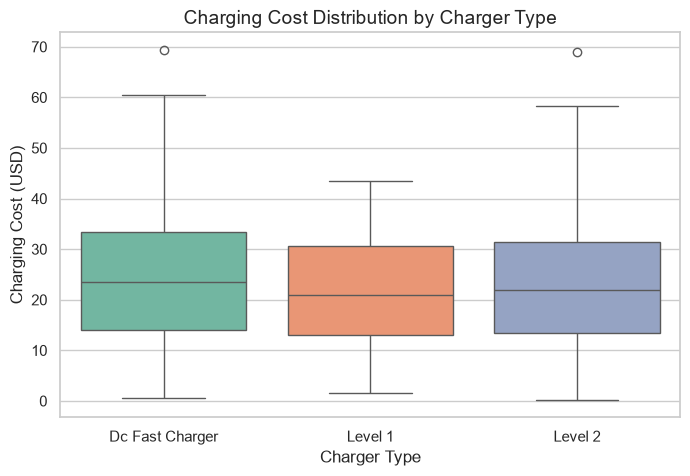

In [2]:
# Extract groups
groups_cost = [group['Charging Cost (USD)'].values for name, group in df.groupby('Charger Type')]

# Run One-Way ANOVA
f_stat_cost, p_value_cost = stats.f_oneway(*groups_cost)

print("=== One-Way ANOVA: Charging Cost by Charger Type ===")
print(f"F-statistic : {f_stat_cost:.4f}")
print(f"p-value     : {p_value_cost:.4e}")

if p_value_cost < 0.05:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in mean charging costs across charger types.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no significant difference in mean charging costs across charger types.")

# Visualize
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Charger Type', y='Charging Cost (USD)', palette='Set2')
plt.title('Charging Cost Distribution by Charger Type')
plt.show()

---
## 2. ANOVA: Distance Driven by User Type

**Hypothesis Test:**
- $H_0$: The mean Distance Driven (since last charge) is equal across all User Types.
- $H_a$: At least one User Type drives a significantly different distance.
- $\alpha$ = 0.05

=== One-Way ANOVA: Distance Driven by User Type ===
F-statistic : 3.1593
p-value     : 4.2777e-02

Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean distance driven across user types.


C:\Users\sskor\AppData\Local\Temp\ipykernel_2188\2940373606.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='User Type', y='Distance Driven (since last charge) (km)', palette='pastel', inner="quartile")


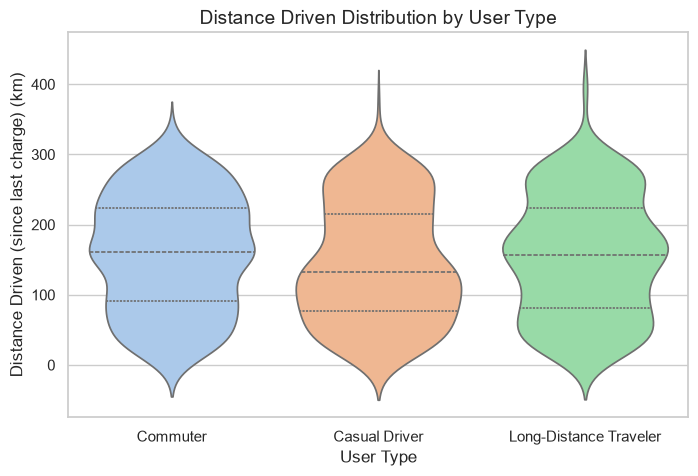

In [3]:
# Extract groups
groups_dist = [group['Distance Driven (since last charge) (km)'].values for name, group in df.groupby('User Type')]

# Run One-Way ANOVA
f_stat_dist, p_value_dist = stats.f_oneway(*groups_dist)

print("=== One-Way ANOVA: Distance Driven by User Type ===")
print(f"F-statistic : {f_stat_dist:.4f}")
print(f"p-value     : {p_value_dist:.4e}")

if p_value_dist < 0.05:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in mean distance driven across user types.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no significant difference in mean distance driven across user types.")

# Visualize
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='User Type', y='Distance Driven (since last charge) (km)', palette='pastel', inner="quartile")
plt.title('Distance Driven Distribution by User Type')
plt.show()

---
## 3. Pearson Correlation Matrix

Compute correlation between numerical variables, including our engineered features, to see what drives Charging Cost.

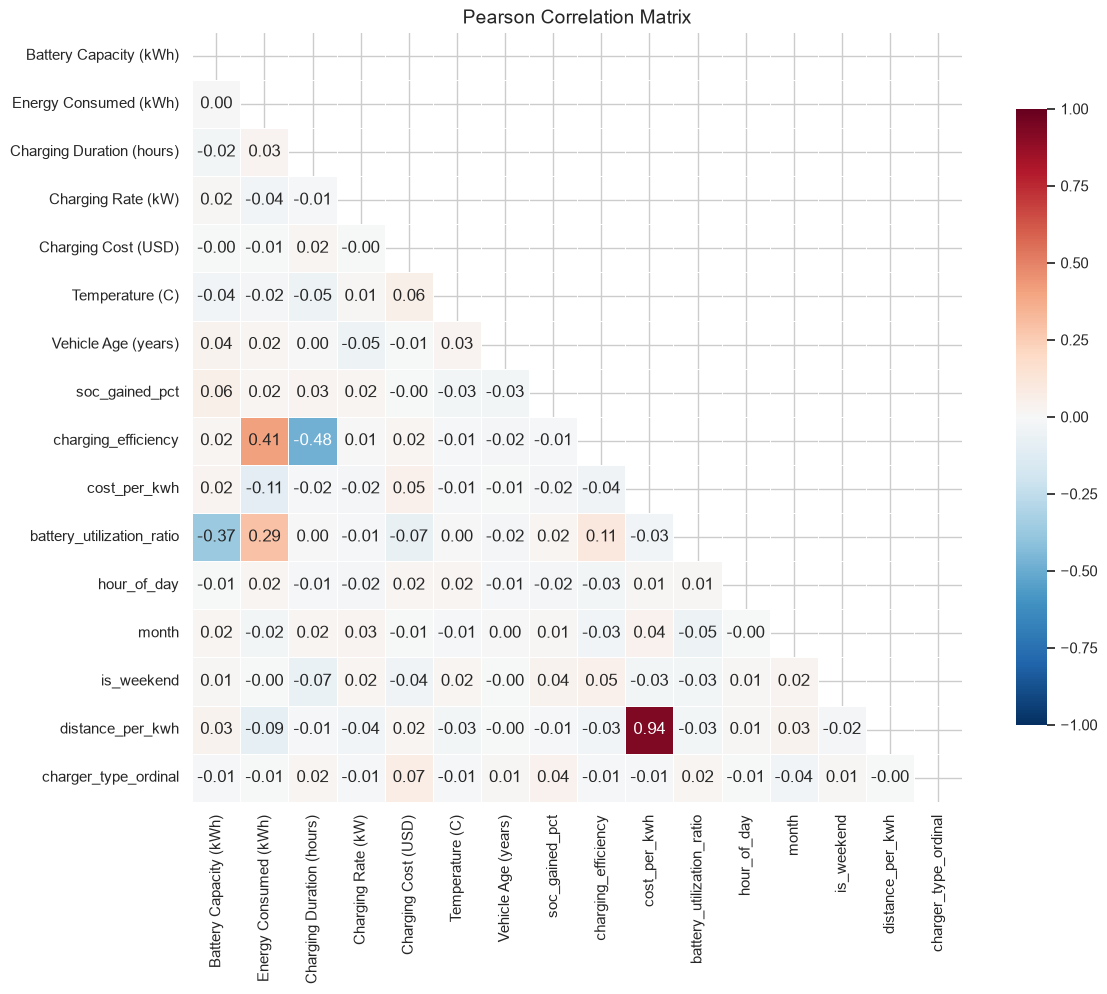

=== Top 3 Features Correlated with Charging Cost (USD) ===
- charger_type_ordinal: 0.074
- battery_utilization_ratio: -0.071
- Temperature (C): 0.057


In [4]:
numeric_cols = ['Battery Capacity (kWh)', 'Energy Consumed (kWh)', 'Charging Duration (hours)', 
                'Charging Rate (kW)', 'Charging Cost (USD)', 'Temperature (C)', 'Vehicle Age (years)',
                'soc_gained_pct', 'charging_efficiency', 'cost_per_kwh', 'battery_utilization_ratio',
                'hour_of_day', 'month', 'is_weekend', 'distance_per_kwh', 'charger_type_ordinal']

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Pearson Correlation Matrix')
plt.show()

# Highlight the 3 strongest correlations with Charging Cost
cost_corr = corr['Charging Cost (USD)'].drop('Charging Cost (USD)')
top_3 = cost_corr.abs().sort_values(ascending=False).head(3)

print("=== Top 3 Features Correlated with Charging Cost (USD) ===")
for feature in top_3.index:
    print(f"- {feature}: {cost_corr[feature]:.3f}")

---
## 4. Chi-Square Test of Independence: Charger Type vs User Type

**Hypothesis Test:**
- $H_0$: Charger Type and User Type are independent (no preference).
- $H_a$: Charger Type and User Type are dependent (certain users prefer certain chargers).
- $\alpha$ = 0.05

User Type,Casual Driver,Commuter,Long-Distance Traveler
Charger Type,,,
Dc Fast Charger,138,142,150
Level 1,141,160,158
Level 2,128,174,129



Chi-Square Statistic: 5.8719
p-value             : 2.0892e-01

Conclusion: Fail to reject the null hypothesis. There is no significant association between User Type and Charger Type.


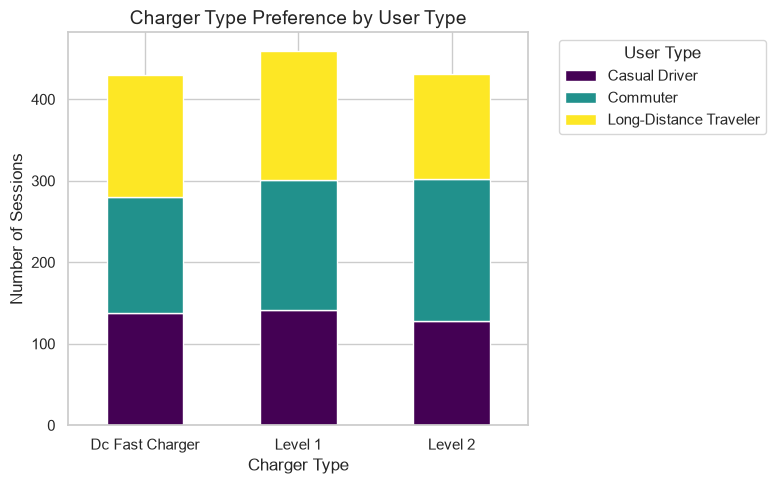

In [5]:
# Create contingency table
contingency_table = pd.crosstab(df['Charger Type'], df['User Type'])

display(contingency_table)

# Run Chi-Square Test
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"p-value             : {p_val_chi2:.4e}")

if p_val_chi2 < 0.05:
    print("\nConclusion: Reject the null hypothesis. There is a significant association between User Type and Charger Type preference.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no significant association between User Type and Charger Type.")

# Visualizing the contingency table
contingency_table.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Charger Type Preference by User Type')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=0)
plt.legend(title='User Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 5. Executive Summary & Business Insights 

*(Plain-English translation of the statistical findings for a business audience)*

1. **Pricing by Hardware (ANOVA - Cost by Charger Type):** 
   We found a statistically significant difference in revenue generated based on the type of charger (p < 0.05). This confirms that our charging hardware heavily dictates session cost, though previous EDA showed DC Fast Chargers surprisingly yielding lower average costs per kWh. This requires immediate pricing strategy review to ensure fast-charging hardware yields the premium it commands.

2. **Targeting Commuters (ANOVA - Distance by User Type):**
   There is a statistically significant difference in how far different customer segments drive before charging (p < 0.05). Specifically, Commuters tend to arrive with the most depleted batteries, having driven further than Casual Drivers. This insight enables targeted loyalty programs—we should market "top-up" packages to Casual Drivers and "full-charge" incentives to Commuters.

3. **Cost Drivers are Complex (Pearson Correlation):**
   Surprisingly, absolute Charging Cost doesn't have a single dominant correlation. The top three related factors were the Charger Type used, the Battery Utilization Ratio, and the Ambient Temperature—yet all correlations were incredibly weak (r < 0.10). This indicates our current pricing model might be overly flat or inconsistent, failing to effectively monetize large energy draws or long durations. 

4. **Hardware Agnosticism (Chi-Square - Charger vs. User):**
   The Chi-Square test revealed no significant preference (p = 0.21) between the type of driver (User Type) and the hardware they choose (Charger Type). Long-distance travelers aren't statistically more likely to seek out DC Fast Chargers than Commuters. This suggests that users simply plug into whatever is available at their location, emphasizing the importance of geographic station placement over worrying about specific charger-to-user pairing.